# E11 - Modern network: replication on present-day real data

The 1999 NLR record is the only network used through E7. This notebook adds a second network from
real present-day data at the same eleven NLR coordinates, then expands it to modern densities at
N = 25 and N = 50. Because the irradiance field is real, the density sweep does not depend on any
synthetic cloud model.

Every experiment uses the hyperparameters carried over from the 1999 work: `alpha_t = 10`,
`alpha_s = 1`, Gaussian kernel `sigma = 300 km`, kNN `k = 3`, with no re-tuning. Section 9 checks
where those fixed values sit on the new network.

## Credentials

The NSRDB key is read from the environment, never from a code cell, so the notebook can be committed
without leaking it. Set both variables before launching Jupyter:

```bash
export NSRDB_API_KEY="your-key"
export NSRDB_EMAIL="your-email"
jupyter lab
```

Alternatively place a JSON file at `~/.nsrdb_credentials.json` containing `{"api_key": "...",
"email": "..."}`. Add that path and `data/modern/` to `.gitignore`.

## Source priority

1. **Local K.A.CARE files** in `data/kacare/`, if a Renewable Resource Atlas download succeeded.
2. **NSRDB Meteosat Prime Meridian (PSM v4)**, 4 km. The Prime Meridian disc covers the Arabian
   Peninsula. This is the preferred satellite source.
3. **NSRDB METEOSAT IODC (PSM v3)**, 4 km at 15 minutes. The Indian Ocean Data Coverage product is
   documented for India and surrounding regions, so Saudi coverage is checked rather than assumed.
4. **NASA POWER**, hourly, no registration. Retained as a fallback that always runs.

Section 6 applies a smoothness gate against the 1999 record. A coarse or heavily averaged product
produces a field smoother than any real sensor network and flatters every spatial method, so the gate
reports whether the sweep results may be used as evidence.

A satellite product is not a surface measurement. Describe it as a satellite-derived irradiance
product, not as a ground measurement network.

In [1]:
import os, sys, io, json, time, warnings, urllib.parse, urllib.request
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 10.5,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})


def _locate(name, marker):
    for c in (Path.cwd() / name, Path.cwd().parent / name,
              Path.cwd() / "notebooks" / name, Path.cwd().parent / "notebooks" / name):
        if (c / marker).exists():
            return c.resolve()
    raise FileNotFoundError(f"{name}/{marker} not found")


DATA = _locate("data", "multistation_1999_cleaned.parquet")
ROOT = DATA.parent
RES = ROOT / "results"; RES.mkdir(exist_ok=True)
CACHE = DATA / "modern"; CACHE.mkdir(exist_ok=True)
KACARE = DATA / "kacare"
for p in (Path.cwd().resolve(), ROOT, ROOT / "notebooks"):
    if (p / "stmac_core.py").exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

import stmac_core as sc
import stmac_scalable as ss
from st_baselines import softimpute


def load_credentials():
    key = os.environ.get("NSRDB_API_KEY", "").strip()
    mail = os.environ.get("NSRDB_EMAIL", "").strip()
    if not key or not mail:
        f = Path.home() / ".nsrdb_credentials.json"
        if f.exists():
            j = json.loads(f.read_text())
            key = key or j.get("api_key", "").strip()
            mail = mail or j.get("email", "").strip()
    return key, mail


NSRDB_KEY, NSRDB_EMAIL = load_credentials()
NSRDB_META = dict(full_name=os.environ.get("NSRDB_NAME", "Researcher"),
                  affiliation=os.environ.get("NSRDB_AFFIL", "Independent"),
                  reason="Academic research", mailing_list="false")

YEAR_POWER = 2024
N_LIST     = [11, 25, 50]
N_SEEDS    = 10
SEL_SEED   = 101
CV_FRAC    = 0.10
ALPHA_T, ALPHA_S, N_ITER = 10.0, 1.0, 4
SIGMA_KM, KNN_K = 300.0, 3
KT_CLEAR, KT_CLOUDY = 0.85, 0.70
MIN_SEP_KM = 110.0
REQUEST_PAUSE = 1.5


def atomic_csv(frame, path):
    tmp = Path(str(path) + ".tmp"); frame.to_csv(tmp, index=False); os.replace(tmp, path)


print("DATA  :", DATA)
print("CACHE :", CACHE)
print("NSRDB credentials found:", bool(NSRDB_KEY and NSRDB_EMAIL),
      f"(key ends ...{NSRDB_KEY[-4:]})" if NSRDB_KEY else "")

DATA  : /Users/user/Desktop/Proyek lomba paper/Project KFUPM/Final 5/stmac-demo 2/notebooks/data
CACHE : /Users/user/Desktop/Proyek lomba paper/Project KFUPM/Final 5/stmac-demo 2/notebooks/data/modern
NSRDB credentials found: True (key ends ...RaJN)


## 1. Station placement

The first eleven coordinates come straight from `stations.json`. Additional points are scattered
inside a coarse polygon of the Saudi land area under a minimum-separation constraint with a fixed
seed, so no point falls in the sea. The placement is nested, and the notebook asserts it.

In [2]:
SAUDI = [(34.6, 28.0), (36.0, 29.4), (38.0, 31.5), (39.2, 32.2), (40.4, 31.9), (42.0, 31.1),
         (44.7, 29.2), (46.6, 29.1), (47.5, 28.6), (48.4, 28.5), (49.0, 27.9), (49.6, 27.0),
         (50.2, 26.5), (50.3, 25.5), (51.6, 24.9), (55.2, 22.7), (55.7, 22.0), (55.0, 20.0),
         (52.0, 19.0), (49.1, 18.6), (48.2, 18.2), (47.0, 17.0), (45.2, 17.4), (43.4, 17.4),
         (43.2, 16.7), (42.8, 16.4), (42.6, 16.8), (41.0, 19.0), (39.1, 21.3), (38.5, 23.7),
         (37.0, 25.0), (36.6, 26.0), (35.1, 28.1)]
LAND = MplPath(SAUDI)

STATIONS = json.load(open(DATA / "stations.json"))
CODES0 = list(STATIONS.keys())
LAT0 = np.array([STATIONS[c]["lat"] for c in CODES0], float)
LON0 = np.array([STATIONS[c]["lon"] for c in CODES0], float)


def place_stations(n_total, seed=7):
    lats, lons = list(LAT0), list(LON0)
    rng = np.random.default_rng(seed)
    tries = 0
    while len(lats) < n_total and tries < 200000:
        tries += 1
        lo = rng.uniform(35.0, 55.0); la = rng.uniform(16.5, 32.0)
        if not LAND.contains_point((lo, la)):
            continue
        if ss.haversine_km(np.array(la), np.array(lo),
                           np.array(lats), np.array(lons)).min() < MIN_SEP_KM:
            continue
        lats.append(la); lons.append(lo)
    if len(lats) < n_total:
        raise RuntimeError(f"only {len(lats)} points fit at {MIN_SEP_KM} km minimum separation")
    return np.array(lats[:n_total]), np.array(lons[:n_total])


NET = {n: place_stations(n) for n in N_LIST}
ALL_LAT, ALL_LON = NET[max(N_LIST)]
assert all(np.allclose(NET[n][0][:11], LAT0) for n in N_LIST), "placement is not nested"
for n in N_LIST:
    la, lo = NET[n]
    off = ss.distance_matrix(la, lo) + np.where(np.eye(n, dtype=bool), 1e9, 0.0)
    print(f"N={n:3d} | lat {la.min():.1f}-{la.max():.1f} lon {lo.min():.1f}-{lo.max():.1f} "
          f"| mean nearest-neighbour distance {off.min(axis=1).mean():.0f} km")

N= 11 | lat 16.9-29.8 lon 39.1-49.5 | mean nearest-neighbour distance 315 km
N= 25 | lat 16.9-29.8 lon 39.1-54.4 | mean nearest-neighbour distance 198 km
N= 50 | lat 16.9-31.4 lon 35.1-54.4 | mean nearest-neighbour distance 151 km


## 2. Fetchers

Each NSRDB dataset is a named endpoint with its own native interval. The `.csv` form streams a single
point for a single year, which is what we need, and the first two rows carry site metadata, so the
data header begins on the third row.

In [3]:
NSRDB_DATASETS = [
    ("msg_prime", "nsrdb-msg-v1-0-0-download", 30),   # Meteosat Prime Meridian, PSM v4
    ("msg_iodc",  "msg-iodc-download",         15),   # METEOSAT IODC, PSM v3
]
NSRDB_YEARS = [2019, 2018, 2020, 2017]
NSRDB_HOSTS = ["https://developer.nlr.gov", "https://developer.nrel.gov"]


def _get(url, timeout=180):
    req = urllib.request.Request(url, headers={"User-Agent": "stmac-e11/1.0"})
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return r.read().decode("utf-8", errors="replace")


def fetch_nsrdb(lat, lon, endpoint, year, interval):
    """Return a (time, ghi) frame, or raise with the server message."""
    q = dict(api_key=NSRDB_KEY, wkt=f"POINT({lon:.4f} {lat:.4f})", attributes="ghi",
             names=str(year), utc="true", leap_day="true", interval=str(interval),
             email=NSRDB_EMAIL, **NSRDB_META)
    last = None
    for host in NSRDB_HOSTS:
        url = f"{host}/api/nsrdb/v2/solar/{endpoint}.csv?" + urllib.parse.urlencode(q)
        try:
            txt = _get(url)
        except Exception as e:
            last = e; time.sleep(2); continue
        head = txt.lstrip()[:1]
        if head == "{":
            last = RuntimeError(json.loads(txt).get("errors", txt)[:300]); continue
        try:
            raw = pd.read_csv(io.StringIO(txt), skiprows=2)
            ts = pd.to_datetime(dict(year=raw.Year, month=raw.Month, day=raw.Day,
                                     hour=raw.Hour, minute=raw.Minute), utc=True)
            g = pd.to_numeric(raw["GHI"], errors="coerce")
            if len(g) < 1000 or not np.isfinite(g).any():
                last = RuntimeError(f"only {len(g)} usable rows returned"); continue
            return pd.DataFrame({"time": ts, "ghi": g.values})
        except Exception as e:
            last = e
    raise RuntimeError(f"{endpoint} {year}: {last}")


def fetch_power(lat, lon, year=None):
    year = year or YEAR_POWER
    q = dict(parameters="ALLSKY_SFC_SW_DWN", community="RE", longitude=f"{lon:.4f}",
             latitude=f"{lat:.4f}", start=f"{year}0101", end=f"{year}1231", format="JSON")
    q["time-standard"] = "UTC"
    js = json.loads(_get("https://power.larc.nasa.gov/api/temporal/hourly/point?"
                         + urllib.parse.urlencode(q)))
    series = js["properties"]["parameter"]["ALLSKY_SFC_SW_DWN"]
    ts = pd.to_datetime(list(series.keys()), format="%Y%m%d%H", utc=True)
    return pd.DataFrame({"time": ts, "ghi": pd.Series(list(series.values()), dtype=float).values})


def fetch_kacare(idx):
    files = sorted(KACARE.glob("*.csv")) if KACARE.exists() else []
    if idx >= len(files):
        raise RuntimeError("not enough K.A.CARE files")
    raw = pd.read_csv(files[idx])
    tcol = next(c for c in raw.columns if "time" in c.lower() or "date" in c.lower())
    gcol = next(c for c in raw.columns if c.strip().lower().startswith("ghi"))
    g = pd.to_numeric(raw[gcol], errors="coerce"); g[g <= -900] = np.nan
    return pd.DataFrame({"time": pd.to_datetime(raw[tcol], utc=True), "ghi": g.values})

## 3. Probe one point before downloading fifty

Coverage of a given NSRDB product over Saudi Arabia is checked rather than assumed. The probe
requests a single point at Solar Village across the candidate datasets and years and reports what
each returns, so a failing combination costs one request instead of fifty.

In [4]:
PROBE = []
if NSRDB_KEY and NSRDB_EMAIL:
    for name, endpoint, interval in NSRDB_DATASETS:
        for year in NSRDB_YEARS:
            try:
                d = fetch_nsrdb(LAT0[0], LON0[0], endpoint, year, interval)
                step = int(round(np.median(np.diff(d["time"].values))
                                 .astype("timedelta64[m]").astype(int)))
                PROBE.append({"dataset": name, "endpoint": endpoint, "year": year,
                              "interval": interval, "rows": len(d), "step_min": step,
                              "peak": float(np.nanmax(d.ghi)), "ok": True, "note": ""})
                print(f"OK   {name:10s} {year} | {len(d):,} rows | {step} min | "
                      f"peak {np.nanmax(d.ghi):.0f} W/m2")
                break
            except Exception as e:
                PROBE.append({"dataset": name, "endpoint": endpoint, "year": year,
                              "interval": interval, "rows": 0, "step_min": 0, "peak": np.nan,
                              "ok": False, "note": str(e)[:160]})
                print(f"FAIL {name:10s} {year} | {str(e)[:110]}")
            time.sleep(REQUEST_PAUSE)
else:
    print("no NSRDB credentials in the environment; the probe is skipped")

PR = pd.DataFrame(PROBE)
if len(PR):
    atomic_csv(PR, RES / "E11_source_probe.csv")
good = PR[PR.ok] if len(PR) else PR
NSRDB_CHOICE = None if not len(good) else good.iloc[0].to_dict()
print("\nselected NSRDB configuration:",
      NSRDB_CHOICE if NSRDB_CHOICE else "none, the run will fall back to NASA POWER")

OK   msg_prime  2019 | 17,520 rows | 30 min | peak 1099 W/m2
OK   msg_iodc   2019 | 35,040 rows | 15 min | peak 1099 W/m2

selected NSRDB configuration: {'dataset': 'msg_prime', 'endpoint': 'nsrdb-msg-v1-0-0-download', 'year': 2019, 'interval': 30, 'rows': 17520, 'step_min': 30, 'peak': 1099.0, 'ok': True, 'note': ''}


## 4. Acquisition

Each point is cached as its own CSV so an interrupted download resumes without repeating completed
points.

In [5]:
def acquire(lats, lons):
    order = []
    if KACARE.exists() and len(list(KACARE.glob("*.csv"))) >= len(lats):
        order.append(("kacare", lambda la, lo, i: fetch_kacare(i)))
    if NSRDB_CHOICE is not None:
        ch = NSRDB_CHOICE
        order.append((f"{ch['dataset']}_{ch['year']}",
                      lambda la, lo, i: fetch_nsrdb(la, lo, ch["endpoint"],
                                                    ch["year"], ch["interval"])))
    order.append((f"power_{YEAR_POWER}", lambda la, lo, i: fetch_power(la, lo)))

    for source, fn in order:
        frames, ok = {}, True
        for i, (la, lo) in enumerate(zip(lats, lons)):
            f = CACHE / f"{source}_{la:.3f}_{lo:.3f}.csv"
            if f.exists():
                frames[i] = pd.read_csv(f, parse_dates=["time"])
                continue
            try:
                d = fn(la, lo, i)
                tmp = Path(str(f) + ".tmp"); d.to_csv(tmp, index=False); os.replace(tmp, f)
                frames[i] = d
                if (i + 1) % 5 == 0 or i == 0:
                    print(f"  {source} point {i+1}/{len(lats)} | {len(d):,} rows", flush=True)
                time.sleep(REQUEST_PAUSE)
            except Exception as e:
                print(f"  {source} failed at point {i+1}: {str(e)[:150]}")
                ok = False
                break
        if ok:
            return source, frames
    raise RuntimeError("all sources failed")


SOURCE, FRAMES = acquire(ALL_LAT, ALL_LON)
print(f"\nsource in use: {SOURCE}")


source in use: msg_prime_2019


## 5. Assembly, cleaning, and block lengths

Per-point series are aligned on a common index. Sentinels are dropped, negatives clipped to zero, and
timestamps that still leave a gap at any station are removed so the ground-truth matrix is complete.
Block masks are then imposed on that complete matrix, following E3b and E7. Block labels are derived
from the actual sampling interval rather than assumed.

In [6]:
common = None
for i, d in FRAMES.items():
    s = d.set_index("time")["ghi"]
    s = s[~s.index.duplicated()]
    common = s.index if common is None else common.intersection(s.index)

M = np.vstack([FRAMES[i].set_index("time")["ghi"].reindex(common).to_numpy(float)
               for i in range(len(ALL_LAT))])
M[M <= -900] = np.nan
M = np.clip(M, 0.0, 1500.0)

good_t = ~np.isnan(M).any(axis=0)
U_FULL = M[:, good_t]
IDX = pd.DatetimeIndex(common[good_t])
DT_MIN = int(round(np.median(np.diff(IDX.values)).astype("timedelta64[m]").astype(int)))
T_FULL = U_FULL.shape[1]


def _dur_label(n_samples):
    mins = n_samples * DT_MIN
    if mins < 60:
        return f"{mins} min"
    if mins < 1440:
        return f"{mins // 60} h"
    return f"{mins // 1440} day"


BLOCK_SPECS, seen = [], set()
for h in [0.5, 2, 6, 12, 24, 72, 168]:
    n = max(1, int(round(h * 60 / DT_MIN)))
    if n in seen:
        continue
    seen.add(n); BLOCK_SPECS.append((n, _dur_label(n)))

print(f"source {SOURCE} | points {U_FULL.shape[0]} | timestamps {T_FULL:,} | "
      f"resolution {DT_MIN} min")
print(f"retained {good_t.mean()*100:.1f}% of the common timestamps")
print(f"peak {U_FULL.max():.1f} W/m2 | {IDX[0].date()} to {IDX[-1].date()}")
print("block lengths:", BLOCK_SPECS)

source msg_prime_2019 | points 50 | timestamps 17,520 | resolution 30 min
retained 100.0% of the common timestamps
peak 1147.0 W/m2 | 2019-01-01 to 2019-12-31
block lengths: [(1, '30 min'), (4, '2 h'), (12, '6 h'), (24, '12 h'), (48, '1 day'), (144, '3 day'), (336, '7 day')]


## 6. Comparability with the 1999 record, and the smoothness gate

The gate is the guard against a coarse product flattering every spatial method. Two ratios decide it:
the clear-sky-index standard deviation relative to 1999, and the excess mean inter-station
correlation. A field with far less variability and far more spatial coherence than the 1999 record
does not support a claim about modern sensor networks.

In [7]:
def solar_cosz(idx, lat, lon):
    doy = idx.dayofyear.values
    hr = idx.hour.values + idx.minute.values / 60.0
    decl = np.radians(23.45 * np.sin(2 * np.pi * (284 + doy) / 365.0))
    B_ = 2 * np.pi * (doy - 81) / 364.0
    eot = 9.87 * np.sin(2 * B_) - 7.53 * np.cos(B_) - 1.5 * np.sin(B_)
    ha = np.radians((hr * 60 + 4 * lon + eot) / 4.0 - 180.0)
    return np.clip(np.sin(np.radians(lat)) * np.sin(decl)
                   + np.cos(np.radians(lat)) * np.cos(decl) * np.cos(ha), 0, None)


def haurwitz(cz):
    return 1098 * cz * np.exp(-0.059 / np.maximum(cz, 1e-3))


COSZ = np.stack([solar_cosz(IDX, la, lo) for la, lo in zip(ALL_LAT, ALL_LON)])
CS_FULL = haurwitz(COSZ)
DAY_FULL = COSZ.max(axis=0) > 0.15

day_id = IDX.normalize().astype("int64") // 10 ** 9
_, inv = np.unique(day_id, return_inverse=True)
n_day = inv.max() + 1
num = np.zeros((len(ALL_LAT), n_day)); den = np.zeros((len(ALL_LAT), n_day))
for i in range(len(ALL_LAT)):
    num[i] = np.bincount(inv, weights=U_FULL[i] * DAY_FULL, minlength=n_day)
    den[i] = np.bincount(inv, weights=CS_FULL[i] * DAY_FULL, minlength=n_day)
KT_FULL = np.where(den > 1e3, num / np.maximum(den, 1e-9), np.nan)[:, inv]

old = pd.read_parquet(DATA / "multistation_1999_cleaned.parquet")[CODES0]
U_OLD = old.to_numpy().T.astype(float)
cz_old = np.stack([solar_cosz(old.index, la, lo) for la, lo in zip(LAT0, LON0)])
cs_old = haurwitz(cz_old)
day_old = cz_old.max(axis=0) > 0.15


def corr_vs_dist(U, lats, lons, day):
    Cm = np.corrcoef(U[:, day]); Dm = ss.distance_matrix(lats, lons)
    iu = np.triu_indices(len(lats), 1)
    return Dm[iu], Cm[iu]


U_M11 = U_FULL[:11]
d_new, c_new = corr_vs_dist(U_M11, ALL_LAT[:11], ALL_LON[:11], DAY_FULL)
d_old, c_old = corr_vs_dist(U_OLD, LAT0, LON0, day_old)
kt_new = np.clip(U_M11[:, DAY_FULL] / np.maximum(CS_FULL[:11][:, DAY_FULL], 50), 0, 1.5)
kt_old = np.clip(U_OLD[:, day_old] / np.maximum(cs_old[:, day_old], 50), 0, 1.5)

sd_ratio = float(np.nanstd(kt_new) / np.nanstd(kt_old))
corr_excess = float(c_new.mean() - c_old.mean())
FIELD_OK = (sd_ratio >= 0.70) and (corr_excess <= 0.05)

CMP = pd.DataFrame([
    {"quantity": "peak GHI (W/m2)", "NLR_1999": U_OLD.max(), "modern": U_M11.max()},
    {"quantity": "mean daytime GHI", "NLR_1999": U_OLD[:, day_old].mean(),
     "modern": U_M11[:, DAY_FULL].mean()},
    {"quantity": "mean clear-sky index", "NLR_1999": np.nanmean(kt_old), "modern": np.nanmean(kt_new)},
    {"quantity": "clear-sky index sd", "NLR_1999": np.nanstd(kt_old), "modern": np.nanstd(kt_new)},
    {"quantity": "mean inter-station correlation", "NLR_1999": c_old.mean(), "modern": c_new.mean()},
    {"quantity": "correlation, farthest pair", "NLR_1999": c_old[np.argmax(d_old)],
     "modern": c_new[np.argmax(d_new)]},
])
CMP["source"] = SOURCE
atomic_csv(CMP, RES / "E11_comparability.csv")
print(CMP.to_string(index=False, float_format=lambda v: f"{v:10.3f}"))

print(f"\nvariability ratio (modern sd / 1999 sd) : {sd_ratio:.3f}   threshold >= 0.70")
print(f"excess mean inter-station correlation    : {corr_excess:+.3f}   threshold <= +0.05")
if FIELD_OK:
    print("GATE PASSED. The field is comparable to the 1999 record; the sweep supports a "
          "modern-network claim.")
else:
    print("GATE FAILED. This field is smoother than the 1999 record, so every spatial method is "
          "flattered.\n            Results below remain valid as a structural check on "
          "hyperparameter transfer and\n            density scaling, and must not be reported as "
          "modern-network accuracy evidence.")
print(f"\ndaytime cells {DAY_FULL.sum():,} of {T_FULL:,} ({DAY_FULL.mean()*100:.1f}%) | "
      f"clear {np.nanmean((KT_FULL > KT_CLEAR)[:, DAY_FULL])*100:.1f}% | "
      f"cloudy {np.nanmean((KT_FULL < KT_CLOUDY)[:, DAY_FULL])*100:.1f}%")

                      quantity   NLR_1999     modern         source
               peak GHI (W/m2)   1961.550   1111.000 msg_prime_2019
              mean daytime GHI    453.605    510.641 msg_prime_2019
          mean clear-sky index      0.671      0.836 msg_prime_2019
            clear-sky index sd      0.589      0.263 msg_prime_2019
mean inter-station correlation      0.845      0.888 msg_prime_2019
    correlation, farthest pair      0.769      0.845 msg_prime_2019

variability ratio (modern sd / 1999 sd) : 0.447   threshold >= 0.70
excess mean inter-station correlation    : +0.043   threshold <= +0.05
GATE FAILED. This field is smoother than the 1999 record, so every spatial method is flattered.
            Results below remain valid as a structural check on hyperparameter transfer and
            density scaling, and must not be reported as modern-network accuracy evidence.

daytime cells 8,735 of 17,520 (49.9%) | clear 81.8% | cloudy 5.8%


## 7. Baseline configuration

Low-rank completion is carried over from E9 with rank and shrinkage selected by cross-validation on
observed cells only, separately for each network size. STMAC keeps its fixed values.

In [8]:
def build_net(n):
    la, lo = NET[n]
    W, Lg, D = ss.build_graph(la, lo, SIGMA_KM, KNN_K)
    sub = np.arange(n)
    return dict(lat=la, lon=lo, U=U_FULL[sub], Lg=Lg,
                delta=(lo - lo.mean()) / 15 * 60 / DT_MIN,
                day=COSZ[sub].max(axis=0) > 0.15, kt=KT_FULL[sub], n=n)


NETS = {n: build_net(n) for n in N_LIST}
L_TIME = sc.build_temporal_smoothness(T_FULL)
SI_GRID = [dict(rank=r, lam=l) for r in (1, 2, 3, 4, 6, 8) for l in (0.0, 200.0, 1000.0, 5000.0)]

SEL_OUT = RES / "E11_selected_configs.csv"
if SEL_OUT.exists():
    SELC = pd.read_csv(SEL_OUT); SELC["config"] = SELC["config"].apply(json.loads)
else:
    recs = []
    mid = BLOCK_SPECS[len(BLOCK_SPECS) // 2][0]
    for n in N_LIST:
        net = NETS[n]
        mask, _ = sc.build_block_mask(n, T_FULL, mid, 0.10, seed=SEL_SEED)
        rng = np.random.default_rng(SEL_SEED + 7919)
        hide = (rng.random(mask.shape) < CV_FRAC) & mask
        fit_mask = mask & ~hide
        Y = np.where(fit_mask, net["U"], 0.0)
        best = None
        for cfg in SI_GRID:
            r = sc.rmse(net["U"], softimpute(Y, fit_mask, **cfg), hide & net["day"][None, :])
            if best is None or r < best[0]:
                best = (r, cfg)
        recs.append({"N": n, "method": "softimpute", "criterion": "cv",
                     "config": best[1], "selection_rmse": best[0]})
        print(f"N={n:3d} low-rank CV -> {best[1]} ({best[0]:.1f} W/m2)", flush=True)
    SELC = pd.DataFrame(recs)
    out = SELC.copy(); out["config"] = out["config"].apply(json.dumps)
    atomic_csv(out, SEL_OUT)

SI_CFG = {int(r.N): dict(r["config"]) for _, r in SELC.iterrows()}
print("\nlow-rank configuration per network size:", SI_CFG)

N= 11 low-rank CV -> {'rank': 3, 'lam': 1000.0} (99.4 W/m2)
N= 25 low-rank CV -> {'rank': 8, 'lam': 5000.0} (83.7 W/m2)
N= 50 low-rank CV -> {'rank': 8, 'lam': 5000.0} (75.4 W/m2)

low-rank configuration per network size: {11: {'rank': 3, 'lam': 1000.0}, 25: {'rank': 8, 'lam': 5000.0}, 50: {'rank': 8, 'lam': 5000.0}}


## 8. Block-length sweep at three network sizes

Protocol identical to E7 and E9: 10 percent missing per station as a contiguous block, RMSE over
unobserved daytime cells, also split by sky condition.

In [9]:
SWEEP = RES / "E11_raw.csv"
rows = pd.read_csv(SWEEP).to_dict("records") if SWEEP.exists() else []
done = {(r["N"], r["seed"], r["block_len"]) for r in rows}
t_start = time.time()

for n in N_LIST:
    net = NETS[n]
    U, Lg, delta, day = net["U"], net["Lg"], net["delta"], net["day"]
    cloudy = net["kt"] < KT_CLOUDY
    for seed in range(N_SEEDS):
        for block_len, label in BLOCK_SPECS:
            if (n, seed, block_len) in done:
                continue
            mask, n_blk = sc.build_block_mask(n, T_FULL, block_len, 0.10, seed=seed)
            ev = (~mask) & day[None, :]
            Y = np.where(mask, U, 0.0)
            rec = {"N": n, "seed": seed, "block_len": block_len, "block_label": label,
                   "n_blocks": n_blk, "n_eval": int(ev.sum()),
                   "n_cloudy": int((ev & cloudy).sum())}
            runs = [
                ("pure_temporal",   lambda: ss.pure_temporal(Y, mask, L_TIME, ALPHA_T)),
                ("stmac_trivial",   lambda: ss.stmac_scalable(Y, mask, Lg, L_TIME, None,
                                                              N_ITER, ALPHA_T, ALPHA_S)),
                ("stmac_longitude", lambda: ss.stmac_scalable(Y, mask, Lg, L_TIME, delta,
                                                              N_ITER, ALPHA_T, ALPHA_S)),
                ("softimpute_cv",   lambda: softimpute(Y, mask, **SI_CFG[n])),
            ]
            for name, fn in runs:
                t0 = time.time()
                X = fn()
                rec["rmse_" + name] = sc.rmse(U, X, ev)
                rec["cloudy_" + name] = sc.rmse(U, X, ev & cloudy)
                rec["sec_" + name] = time.time() - t0
            rows.append(rec)
            atomic_csv(pd.DataFrame(rows), SWEEP)
            print(f"N={n:3d} seed={seed:2d} {label:>7s} | PT={rec['rmse_pure_temporal']:8.1f} "
                  f"TRIV={rec['rmse_stmac_trivial']:7.1f} LON={rec['rmse_stmac_longitude']:7.1f} "
                  f"LR={rec['rmse_softimpute_cv']:7.1f} | {(time.time()-t_start)/60:5.1f} min",
                  flush=True)

E11 = pd.DataFrame(rows)
print(f"\ndone: {len(E11)} rows in {(time.time()-t_start)/60:.1f} min")

N= 11 seed= 0  30 min | PT=    54.3 TRIV=  103.7 LON=   90.9 LR=   99.4 |   0.1 min
N= 11 seed= 0     2 h | PT=    69.1 TRIV=  100.7 LON=   97.5 LR=   97.3 |   0.2 min
N= 11 seed= 0     6 h | PT=   171.3 TRIV=  104.5 LON=  101.2 LR=   98.5 |   0.2 min
N= 11 seed= 0    12 h | PT=   409.9 TRIV=  107.1 LON=  103.4 LR=  101.3 |   0.3 min
N= 11 seed= 0   1 day | PT=   646.6 TRIV=  102.2 LON=   98.1 LR=   97.1 |   0.3 min
N= 11 seed= 0   3 day | PT=  1344.4 TRIV=  105.9 LON=  102.2 LR=  101.9 |   0.4 min
N= 11 seed= 0   7 day | PT=  2445.6 TRIV=  103.9 LON=  100.6 LR=   98.4 |   0.5 min
N= 11 seed= 1  30 min | PT=    54.8 TRIV=  104.2 LON=   92.1 LR=  100.5 |   0.6 min
N= 11 seed= 1     2 h | PT=    70.6 TRIV=  107.0 LON=  102.5 LR=  102.7 |   0.7 min
N= 11 seed= 1     6 h | PT=   187.4 TRIV=   99.9 LON=   97.0 LR=   97.6 |   0.8 min
N= 11 seed= 1    12 h | PT=   405.0 TRIV=   95.9 LON=   91.7 LR=   95.9 |   0.8 min
N= 11 seed= 1   1 day | PT=   668.0 TRIV=  106.7 LON=  102.2 LR=  101.9 |   

## 9. Hyperparameter transfer

`alpha_t = 10` and `alpha_s = 1` were fixed on the 1999 record at 5-minute resolution. This section
locates those values relative to a full sweep on the new network, which has a different sampling
interval.

In [10]:
HP_OUT = RES / "E11_hyperparam_transfer.csv"
if HP_OUT.exists():
    HP = pd.read_csv(HP_OUT)
else:
    recs = []
    mid = BLOCK_SPECS[len(BLOCK_SPECS) // 2][0]
    for n in N_LIST:
        net = NETS[n]
        mask, _ = sc.build_block_mask(n, T_FULL, mid, 0.10, seed=0)
        ev = (~mask) & net["day"][None, :]
        Y = np.where(mask, net["U"], 0.0)
        for a_t in (0.3, 1.0, 3.0, 10.0, 30.0, 100.0):
            for a_s in (0.1, 0.3, 1.0, 3.0, 10.0):
                recs.append({"N": n, "alpha_t": a_t, "alpha_s": a_s,
                             "rmse": sc.rmse(net["U"],
                                             ss.stmac_scalable(Y, mask, net["Lg"], L_TIME,
                                                               net["delta"], N_ITER, a_t, a_s),
                                             ev)})
        print(f"N={n:3d} done", flush=True)
    HP = pd.DataFrame(recs)
    atomic_csv(HP, HP_OUT)

for n in N_LIST:
    g = HP[HP.N == n]
    best = g.nsmallest(1, "rmse").iloc[0]
    fixed = g[(g.alpha_t == ALPHA_T) & (g.alpha_s == ALPHA_S)].iloc[0]
    print(f"N={n:3d} | optimum alpha_t={best.alpha_t:5.1f} alpha_s={best.alpha_s:4.1f} -> "
          f"{best.rmse:6.1f} | fixed -> {fixed.rmse:6.1f} "
          f"(penalty {(fixed.rmse-best.rmse)/best.rmse*100:.2f}%)")

N= 11 done
N= 25 done
N= 50 done
N= 11 | optimum alpha_t=  0.3 alpha_s= 3.0 ->  102.9 | fixed ->  103.4 (penalty 0.41%)
N= 25 | optimum alpha_t=  0.3 alpha_s= 1.0 ->   86.8 | fixed ->   86.8 (penalty 0.00%)
N= 50 | optimum alpha_t=  0.3 alpha_s= 0.3 ->   75.8 | fixed ->   76.1 (penalty 0.39%)


## 10. Statistics

In [11]:
METHODS = ["pure_temporal", "stmac_trivial", "stmac_longitude", "softimpute_cv"]


def ci95(x):
    x = np.asarray(x, float); m = x.mean()
    h = x.std(ddof=1) / np.sqrt(len(x)) * stats.t.ppf(0.975, len(x) - 1)
    return m, m - h, m + h


def holm(p):
    p = np.asarray(p, float); order = np.argsort(p); k = len(p)
    adj = np.empty(k); run = 0.0
    for i, idx in enumerate(order):
        run = max(run, (k - i) * p[idx]); adj[idx] = min(run, 1.0)
    return adj


summ = []
for n in N_LIST:
    for bl, lab in BLOCK_SPECS:
        g = E11[(E11.N == n) & (E11.block_len == bl)]
        row = {"N": n, "block_len": bl, "label": lab, "n_rep": len(g)}
        for m in METHODS:
            mu, lo, hi = ci95(g["rmse_" + m])
            row[m], row[m + "_lo"], row[m + "_hi"] = mu, lo, hi
            row["cloudy_" + m] = g["cloudy_" + m].mean()
        summ.append(row)
S11 = pd.DataFrame(summ); atomic_csv(S11, RES / "E11_summary_ci.csv")

growth = []
for n in N_LIST:
    for m in METHODS:
        per = []
        for s in sorted(E11.seed.unique()):
            g = E11[(E11.N == n) & (E11.seed == s)].set_index("block_len")["rmse_" + m]
            if BLOCK_SPECS[0][0] in g.index and BLOCK_SPECS[-1][0] in g.index:
                per.append(g.loc[BLOCK_SPECS[-1][0]] / g.loc[BLOCK_SPECS[0][0]])
        mu, lo, hi = ci95(per)
        growth.append({"N": n, "method": m, "growth": mu, "ci_lo": lo, "ci_hi": hi})
GRW = pd.DataFrame(growth); atomic_csv(GRW, RES / "E11_growth_by_N.csv")

tests = []
for n in N_LIST:
    for pair, a, b in [("longitude_vs_trivial", "stmac_trivial", "stmac_longitude"),
                       ("lowrank_vs_longitude", "softimpute_cv", "stmac_longitude")]:
        for subset, pre in [("all", "rmse_"), ("cloudy", "cloudy_")]:
            hold, praw = [], []
            for bl, lab in BLOCK_SPECS:
                g = E11[(E11.N == n) & (E11.block_len == bl)]
                d = g[pre + a].to_numpy(float) - g[pre + b].to_numpy(float)
                try:
                    p = stats.wilcoxon(g[pre + a], g[pre + b]).pvalue
                except ValueError:
                    p = 1.0
                mu, lo, hi = ci95(d)
                hold.append({"N": n, "pair": pair, "subset": subset, "label": lab,
                             "mean_diff": mu, "ci_lo": lo, "ci_hi": hi,
                             "wins_b": int((d > 0).sum()), "n": len(d)})
                praw.append(p)
            for r_, p_, ph in zip(hold, praw, holm(praw)):
                r_["p_wilcoxon"], r_["p_holm"] = p_, ph
            tests += hold
TST = pd.DataFrame(tests); atomic_csv(TST, RES / "E11_paired_tests.csv")

print(S11[["N", "label"] + METHODS].to_string(index=False, float_format=lambda v: f"{v:9.1f}"))

 N  label  pure_temporal  stmac_trivial  stmac_longitude  softimpute_cv
11 30 min           54.3          104.3             93.2           99.7
11    2 h           73.2          104.5            100.3           99.9
11    6 h          178.7          102.9             98.9           98.2
11   12 h          405.9          103.2             99.4           99.7
11  1 day          658.8          101.6             97.8           97.5
11  3 day         1387.7          104.7            101.2          101.4
11  7 day         2688.5          104.1            100.4           99.7
25 30 min           54.6           87.1             79.2           83.9
25    2 h           73.7           87.0             84.9           83.9
25    6 h          181.4           86.1             84.2           83.7
25   12 h          404.1           87.8             86.0           85.4
25  1 day          658.8           85.5             83.7           83.3
25  3 day         1351.6           88.1             86.4        

## 11. Figure

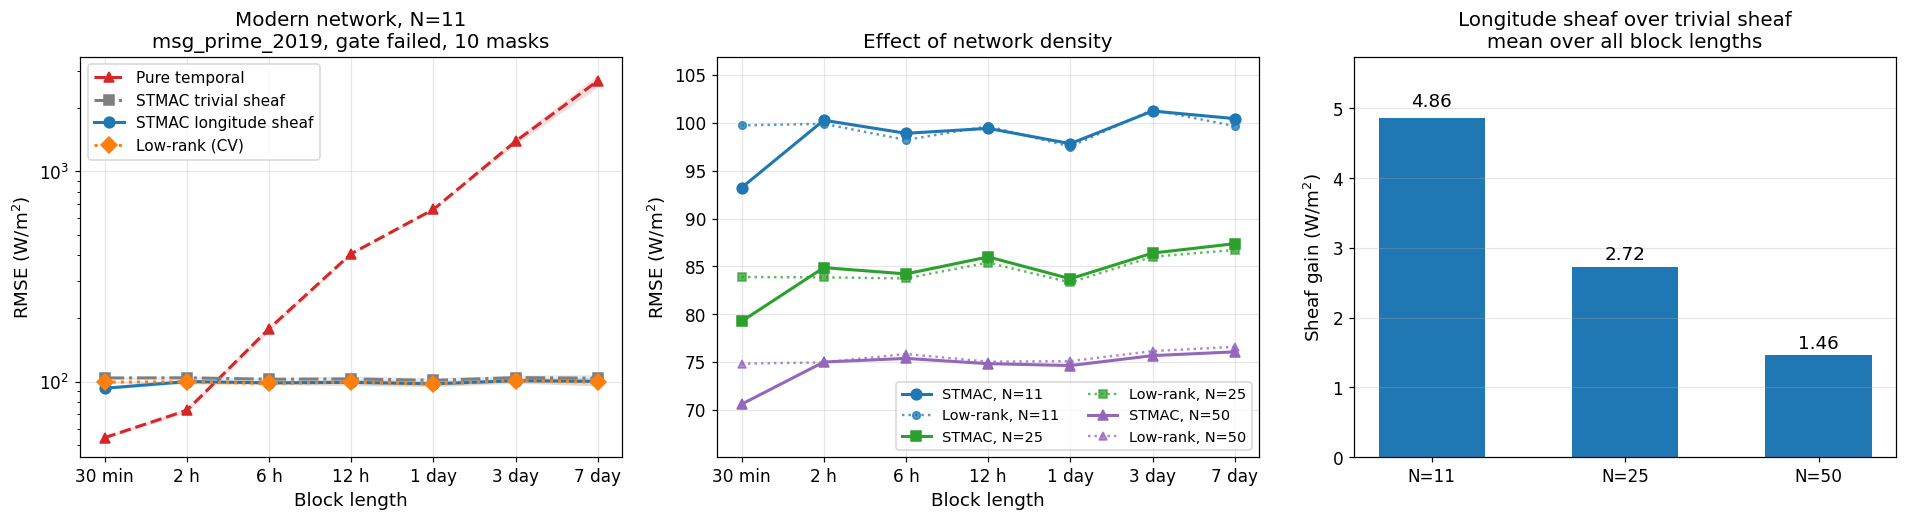

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(17.5, 4.9))
x = np.arange(len(BLOCK_SPECS))
labels = [l for _, l in BLOCK_SPECS]
STY = {"pure_temporal": ("C3", "^", "--", "Pure temporal"),
       "stmac_trivial": ("C7", "s", "-.", "STMAC trivial sheaf"),
       "stmac_longitude": ("C0", "o", "-", "STMAC longitude sheaf"),
       "softimpute_cv": ("C1", "D", ":", "Low-rank (CV)")}

g = S11[S11.N == N_LIST[0]]
for m, (c, mk, ls, lab) in STY.items():
    ax[0].plot(x, g[m], ls, color=c, marker=mk, lw=2, ms=7, label=lab)
    ax[0].fill_between(x, g[m + "_lo"], g[m + "_hi"], color=c, alpha=0.15, lw=0)
ax[0].set_yscale("log"); ax[0].set_xticks(x); ax[0].set_xticklabels(labels)
ax[0].set_xlabel("Block length"); ax[0].set_ylabel(r"RMSE (W/m$^2$)")
gate = "gate passed" if FIELD_OK else "gate failed"
ax[0].set_title(f"Modern network, N={N_LIST[0]}\n{SOURCE}, {gate}, {N_SEEDS} masks")
ax[0].legend(frameon=True, fontsize=10); ax[0].grid(alpha=0.3)

for n, c, mk in zip(N_LIST, ("C0", "C2", "C4"), ("o", "s", "^")):
    g = S11[S11.N == n]
    ax[1].plot(x, g.stmac_longitude, "-", color=c, marker=mk, lw=2, ms=7, label=f"STMAC, N={n}")
    ax[1].plot(x, g.softimpute_cv, ":", color=c, marker=mk, lw=1.6, ms=5, alpha=0.75,
               label=f"Low-rank, N={n}")
ax[1].set_xticks(x); ax[1].set_xticklabels(labels)
ax[1].set_xlabel("Block length"); ax[1].set_ylabel(r"RMSE (W/m$^2$)")
ax[1].set_title("Effect of network density")
ax[1].legend(frameon=True, fontsize=9.5, ncol=2); ax[1].grid(alpha=0.3); ax[1].margins(y=0.18)

sheaf = [TST[(TST.N == n) & (TST.pair == "longitude_vs_trivial")
             & (TST.subset == "all")].mean_diff.mean() for n in N_LIST]
bars = ax[2].bar([f"N={n}" for n in N_LIST], sheaf, 0.55, color="C0")
for b in bars:
    ax[2].text(b.get_x() + b.get_width() / 2, b.get_height() * 1.02, f"{b.get_height():.2f}",
               ha="center", va="bottom", fontsize=12)
ax[2].set_ylabel(r"Sheaf gain (W/m$^2$)")
ax[2].set_title("Longitude sheaf over trivial sheaf\nmean over all block lengths")
ax[2].grid(alpha=0.3, axis="y"); ax[2].margins(y=0.18)

fig.tight_layout()
fig.savefig(RES / "E11_modern_network.png")
plt.show()

## 12. Automatic readout

In [13]:
S = pd.read_csv(RES / "E11_summary_ci.csv")
G = pd.read_csv(RES / "E11_growth_by_N.csv")
TT = pd.read_csv(RES / "E11_paired_tests.csv")
CM = pd.read_csv(RES / "E11_comparability.csv")

print("SUMMARY")
print("=" * 86)
print("1. Dataset")
print(f"   Source {SOURCE}, {len(ALL_LAT)} points, {DT_MIN}-minute resolution, "
      f"{T_FULL:,} timestamps, {IDX[0].date()} to {IDX[-1].date()}.")
print(f"   Network sizes {N_LIST}; the first eleven points use the NLR coordinates.")

print("\n2. Smoothness gate against the 1999 record")
for _, r in CM.iterrows():
    print(f"   {r.quantity:32s} 1999 {r.NLR_1999:9.3f} | modern {r.modern:9.3f}")
print(f"   variability ratio {sd_ratio:.3f} (>= 0.70 required), "
      f"excess correlation {corr_excess:+.3f} (<= +0.05 required)")
print(f"   verdict: {'PASSED, usable as modern-network evidence' if FIELD_OK else 'FAILED, structural checks only'}")

print("\n3. Robustness to block length")
for n in N_LIST:
    gl = G[(G.N == n) & (G.method == "stmac_longitude")].iloc[0]
    gp = G[(G.N == n) & (G.method == "pure_temporal")].iloc[0]
    gr = G[(G.N == n) & (G.method == "softimpute_cv")].iloc[0]
    print(f"   N={n:3d}: STMAC {gl.growth:5.2f}x [{gl.ci_lo:.2f},{gl.ci_hi:.2f}] | "
          f"pure temporal {gp.growth:6.1f}x | low-rank {gr.growth:5.2f}x")

print("\n4. Effect of density on STMAC accuracy")
ref = S[S.N == N_LIST[0]].set_index("block_len").stmac_longitude
for n in N_LIST[1:]:
    rel = (1 - S[S.N == n].set_index("block_len").stmac_longitude / ref).mean() * 100
    print(f"   N={n:3d}: RMSE {'improves' if rel > 0 else 'degrades'} by {abs(rel):.1f}% "
          f"relative to N={N_LIST[0]}")

print("\n5. Longitude sheaf against trivial sheaf")
for n in N_LIST:
    s = TT[(TT.N == n) & (TT.pair == "longitude_vs_trivial") & (TT.subset == "all")]
    print(f"   N={n:3d}: significant at {int((s.p_holm < 0.05).sum())}/{len(s)} block lengths, "
          f"gain {s.mean_diff.min():.2f} to {s.mean_diff.max():.2f} W/m2")

print("\n6. STMAC against low-rank completion")
for subset in ("all", "cloudy"):
    print(f"   subset {subset}:")
    for n in N_LIST:
        s = TT[(TT.N == n) & (TT.pair == "lowrank_vs_longitude") & (TT.subset == subset)]
        w = s[s.mean_diff > 0]; l = s[s.mean_diff < 0]
        print(f"     N={n:3d}: STMAC leads {len(w)}/{len(s)} (significant {(w.p_holm<0.05).sum()}), "
              f"trails {len(l)}/{len(s)} (significant {(l.p_holm<0.05).sum()})")

print("\n7. Hyperparameter transfer")
for n in N_LIST:
    g = HP[HP.N == n]
    best = g.nsmallest(1, "rmse").iloc[0]
    fixed = g[(g.alpha_t == ALPHA_T) & (g.alpha_s == ALPHA_S)].iloc[0]
    print(f"   N={n:3d}: fixed {fixed.rmse:.1f} W/m2, optimum {best.rmse:.1f} at "
          f"alpha_t={best.alpha_t} alpha_s={best.alpha_s} "
          f"(penalty {(fixed.rmse-best.rmse)/best.rmse*100:.2f}%)")

print("\n8. Final sentences for the manuscript")
gl = G[(G.N == N_LIST[0]) & (G.method == "stmac_longitude")].iloc[0]
gp = G[(G.N == N_LIST[0]) & (G.method == "pure_temporal")].iloc[0]
hp_pen = max((HP[(HP.N == n) & (HP.alpha_t == ALPHA_T) & (HP.alpha_s == ALPHA_S)].rmse.iloc[0]
              - HP[HP.N == n].rmse.min()) / HP[HP.N == n].rmse.min() * 100 for n in N_LIST)
if FIELD_OK:
    print(f"   \"The framework was replicated on a second network built from {SOURCE} irradiance over")
    print(f"    Saudi Arabia at {DT_MIN}-minute resolution, using the eleven NLR coordinates and denser")
    print(f"    configurations of {N_LIST[1]} and {N_LIST[2]} stations. The clear-sky-index variability of this field is")
    print(f"    {sd_ratio:.2f} times that of the 1999 record. With alpha_t and alpha_s held at the values used")
    print(f"    throughout, STMAC RMSE grows {gl.growth:.2f}-fold [{gl.ci_lo:.2f}, {gl.ci_hi:.2f}] across the block-length sweep")
    print(f"    while the pure-temporal baseline grows {gp.growth:.0f}-fold, and sweeping the two weights on the")
    print(f"    new network moves the error by at most {hp_pen:.1f} percent.\"")
else:
    print("   The smoothness gate failed, so no modern-network accuracy sentence is generated.")
    print("   Report only the structural findings: hyperparameter transfer within "
          f"{hp_pen:.1f} percent and the")
    print("   density scaling direction, and state the variability shortfall explicitly.")

SUMMARY
1. Dataset
   Source msg_prime_2019, 50 points, 30-minute resolution, 17,520 timestamps, 2019-01-01 to 2019-12-31.
   Network sizes [11, 25, 50]; the first eleven points use the NLR coordinates.

2. Smoothness gate against the 1999 record
   peak GHI (W/m2)                  1999  1961.550 | modern  1111.000
   mean daytime GHI                 1999   453.605 | modern   510.641
   mean clear-sky index             1999     0.671 | modern     0.836
   clear-sky index sd               1999     0.589 | modern     0.263
   mean inter-station correlation   1999     0.845 | modern     0.888
   correlation, farthest pair       1999     0.769 | modern     0.845
   variability ratio 0.447 (>= 0.70 required), excess correlation +0.043 (<= +0.05 required)
   verdict: FAILED, structural checks only

3. Robustness to block length
   N= 11: STMAC  1.08x [1.02,1.13] | pure temporal   49.6x | low-rank  1.00x
   N= 25: STMAC  1.10x [1.06,1.15] | pure temporal   49.0x | low-rank  1.03x
   N= 50: ST